# GW parameter estimation with PTMCMC

We use the IMRPhenomD $h_{22}$ waveform model to simulate (noise-free) data and recover the parameters via parallel tempering MCMC. The noise weighted inner product uses the aLIGO theoretical noise PSD. All inner products, likelihood evaluations, etc. are conducted in the frequency-domain.

In [1]:
%load_ext autoreload
%autoreload 2

import lambdasMCMC as lmcmc
import matplotlib.pyplot as plt
import numpy as np
import thermo_error as te
import reddemcee
import wave_gen as wg
from matplotlib import colormaps


In [ ]:
## Only NEED the <lnL> vs beta plot, but DO write functionality to make diagnostic plots like: 
# time/freq-series strain,
# \Delta\Psi vs f, **STARTED
# lnL vs iteration, **STARTED
# \vec{\theta} vs iteration, **STARTED
# Posterior corner plots (for 1-2 arbitrary sets of toggle params) and bayesograms
## lnZs are calculated with thermo_error.py

In [ ]:
### Setup variables
ndim_ = wg.ndim
nw = ndim_ * 2 # number of walkers per ensemble (2x ndim is a good rule of thumb)

setup = (10, nw, 200, 30)
ntemps, nwalkers, nsweeps, nsteps = setup

# Define adaptation parameters according to approximations in Vousden et al 2016 [doi:10.1093/mnras/stv2422]
N=nsweeps*nsteps
tau=10.*N/nw
#nu=N/nw # don't make too big or else dS->0 too quick
nu=0.2 

p0 = np.random.uniform(
    low=wg.x_mins,
    high=wg.x_maxs,
    size=(ntemps, nwalkers, ndim_)
)

print(f'tau, nu = {tau,nu}\ndSs ~ {[round(float(1/nu*(tau/(t+tau))),3) for t in np.linspace(0,N,10)]} for N = {N}')
# ^^ To optimize (if reddemcee doesn't already support the ability to change # of chains during adaptation), 
# loop ALL of this through a range of ntemps and analyze the results (Tmax, T0, etc.) to find the best one

## Create PTSampler object
from likelihood import fast_lnprior as logprior
from likelihood import loglike_untempered_unsuppressed as loglike

sampler = reddemcee.PTSampler(nwalkers, ndim_, loglike, logprior,
                              betas=np.linspace(1, 1e-4, ntemps), # Keep min beta at a small finite number to avoid divide-by-zero errors later
                              adapt_tau=tau,
                              adapt_nu=nu,
                              adapt_mode='SAR')
    
silent = sampler.run_mcmc(p0, nsweeps, nsteps, progress=True)

tau, nu = (4285.714285714285, 0.2)
dSs ~ [5.0, 4.327, 3.814, 3.409, 3.082, 2.812, 2.586, 2.394, 2.228, 2.083] for N = 6000


100%|██████████| 60000/60000 [05:41<00:00, 175.65it/s]


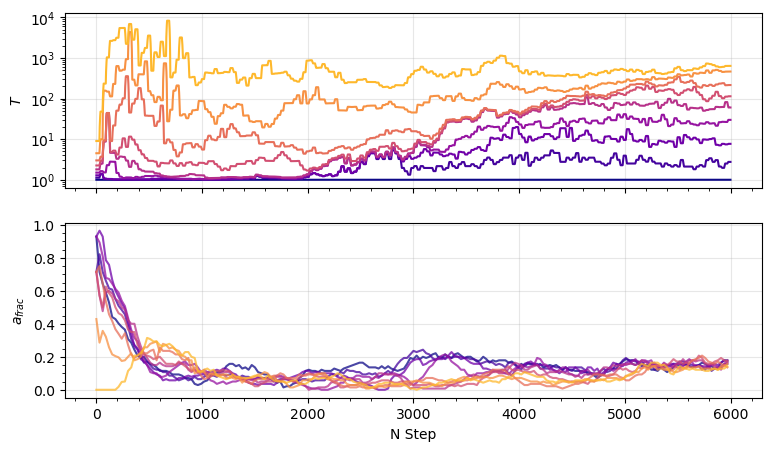

[1.00000000e+00 2.33452689e+00 7.52454005e+00 2.74602440e+01
 6.60878794e+01 1.09150690e+02 2.22314093e+02 4.59565962e+02
 6.19872617e+02 1.00000000e+04]


In [3]:
## Helper functions to olot adaptation of temperatures and acceptance rates
cmap_plasma = colormaps['plasma']
def running(arr, window_size=10):
    """Calculate running average of the last n values
    for better plot visualisation."""
    averages = np.zeros_like(arr)
    for i in range(arr.shape[0]):
        start_idx = max(0, i - window_size + 1)  # Start of the window (avoid negative index)
        averages[i] = np.mean(arr[start_idx:i + 1], axis=0)  # Average of the last `window_size` points
    return averages

def plot_betas_ratios(sampler, setup):
    bh = sampler.get_betas()
    rh = sampler.get_tsw()

    colors = cmap_plasma(np.linspace(0, 0.95, setup[0]))

    fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True)

    for t in range(setup[0]-1):# -2):
        # PLOT BETAS
        y_bet = bh[t]
        axes[0].plot(running(1/y_bet), c=colors[t])

        # PLOT TS_ACCEPTANCE
        x0 = np.arange(setup[2]) * setup[3]
        y_tsw = running(rh[:, t])
        axes[1].plot(x0, y_tsw, alpha=0.75, color=colors[t])

    # plot options
    axes[0].set_ylabel(r"$T$")
    axes[1].set_ylabel(r"$a_{frac}$")
    axes[1].set_xlabel("N Step")
    #axes[0].set_xscale('log')
    axes[0].set_yscale('log')
    axes[0].grid(alpha=0.3)
    axes[1].grid(alpha=0.3)
    axes[0].minorticks_on()
    axes[1].minorticks_on()


    plt.show()

plot_betas_ratios(sampler, setup)

### Collect temperature ladder
# Get betas
adapted_betas=sampler.get_betas()
adapted_betas=adapted_betas[:,np.shape(adapted_betas)[1]-100:] # Cut off everything but the last 100 steps, when the temps are converged on Pacc~0.2
adapted_betas=np.mean(adapted_betas[:,np.shape(adapted_betas)[1]-100:],axis=1) # Take mean from last 100 steps
adapted_Ts=1./adapted_betas # Calculate Ts
print(adapted_Ts)

######### Running PTMCMC #1/2 for lambdavec=$\lambda15$=0.0, $\lambda25$=0.0, $\lambda3$=0.0, $\lambda35$=0.0 #########
Average PT swap acceptance rate: 0.3071370420624152
~~~(temp_ladder, Rbars)~~~
1.0 0.749
2.7 0.745
7.29 0.84
19.68 0.63
53.14 0.785
143.49 0.776
387.42 0.857
1046.04 1.027
2824.3 1.491
7625.6 0.483
20589.11 0.335
55590.61 0.0
~~~(temp_ladder, Pacc)~~~
1.0 0.25582089552238807
2.7 0.2764179104477612
7.29 0.23761194029850746
19.68 0.3426865671641791
53.14 0.26597014925373136
143.49 0.3029850746268657
387.42 0.2519402985074627
1046.04 0.1692537313432836
2824.3 0.07880597014925374
7625.6 0.5217910447761194
20589.11 0.6752238805970149
55590.61 0.0
######### Running PTMCMC #2/2 for lambdavec=$\lambda15$=1.0, $\lambda25$=0.0, $\lambda3$=0.0, $\lambda35$=0.0 #########


c:\Users\johor\OneDrive\Documents\GitHub\GWTails_ParameterEstimation\PTMCMC.py:53: RuntimeWarning: overflow encountered in exp
  acc_ratio = np.exp(log_acc_ratio)


Average PT swap acceptance rate: 0.38516452872281093
~~~(temp_ladder, Rbars)~~~
1.0 0.297
2.7 0.173
7.29 0.202
19.68 0.487
53.14 0.771
143.49 0.625
387.42 0.532
1046.04 0.466
2824.3 0.411
7625.6 0.318
20589.11 0.309
55590.61 0.0
~~~(temp_ladder, Pacc)~~~
1.0 0.03742331288343558
2.7 0.20398773006134968
7.29 0.20245398773006135
19.68 0.2331288343558282
53.14 0.25429447852760734
143.49 0.3717791411042945
387.42 0.4582822085889571
1046.04 0.5217791411042945
2824.3 0.5996932515337423
7625.6 0.658282208588957
20589.11 0.6957055214723926
55590.61 0.0


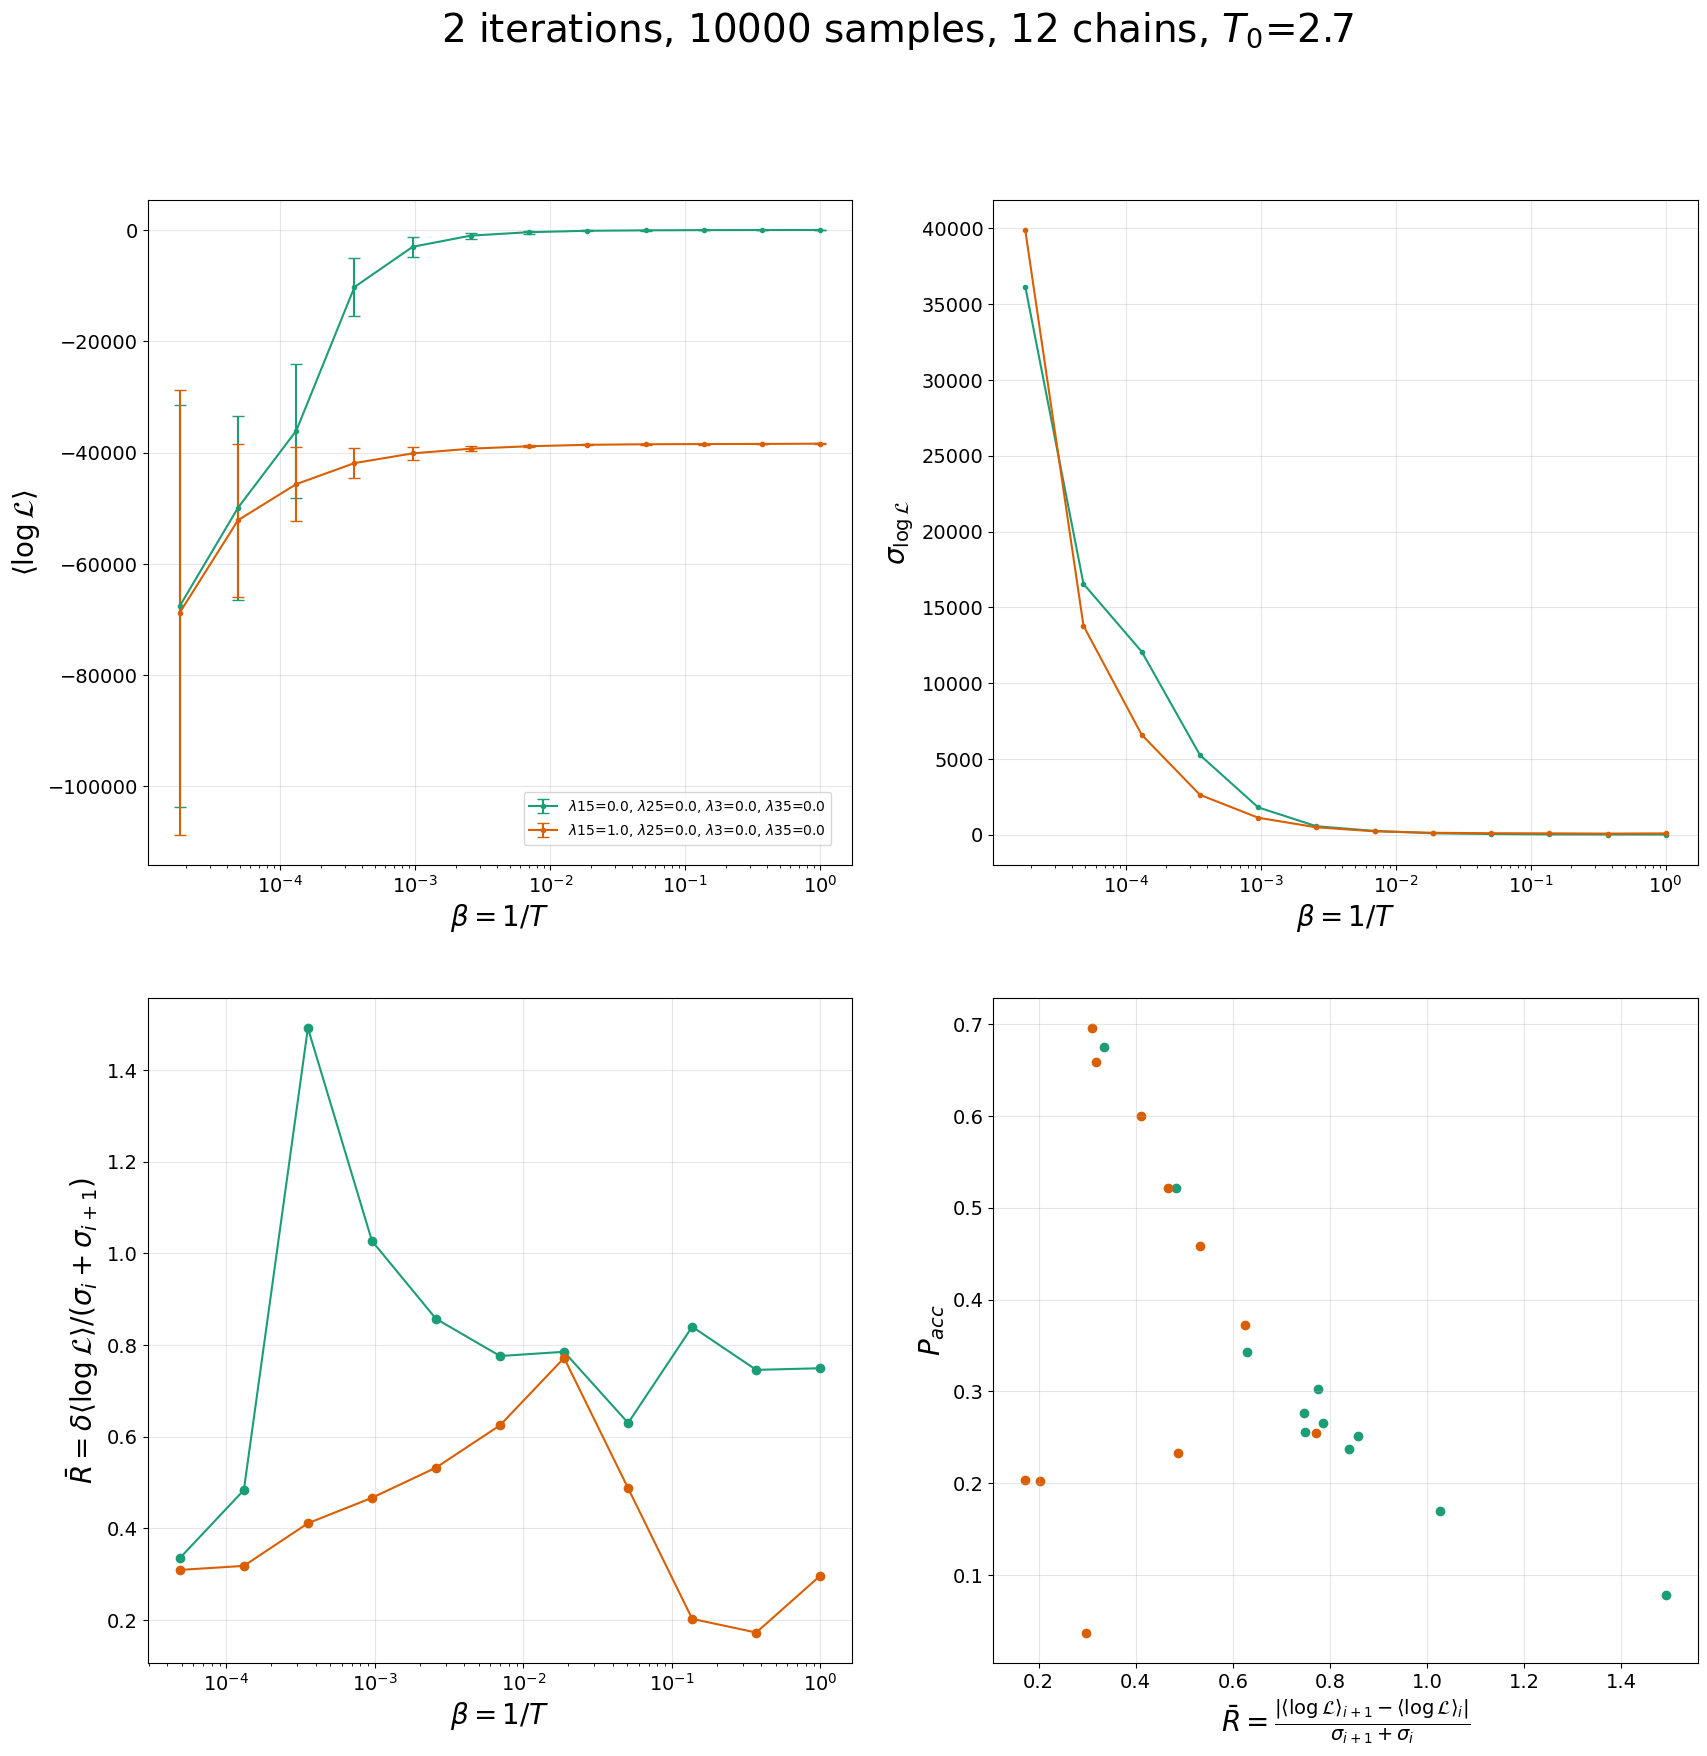

In [ ]:
### With an adapted temperature ladder for 20% acceptance rates...
### Plot <lnL> vs. \beta for each chosen vector of lambda values

lambdas=list(zip(lmcmc.lambda15s, lmcmc.lambda25s, lmcmc.lambda3s, lmcmc.lambda35s))
num_lmcmciters=len(lambdas)

fig,((ax1, ax2), (ax3, ax4)) = plt.subplots(2,2, figsize=(20,19))

colors=lmcmc.itercolors

__TIData__ = np.zeros(num_lmcmciters, dtype=lmcmc.TIData)


# default geometric temperature ladder (to be deprecated by adaptive ladder generation below)
num_samples=10000
num_chains=12
temp0=2.7
temp_ladder=temp0**(np.arange(num_chains))


i=1
for lambda15, lambda25, lambda3, lambda35 in lambdas:
    lambdavec=rf'$\lambda15$={round(lambda15,2)}, $\lambda25$={round(lambda25,2)}, $\lambda3$={round(lambda3,2)}, $\lambda35$={round(lambda35,2)}'
    print(f'######### Running PTMCMC #{i}/{num_lmcmciters} for lambdavec={lambdavec} #########')

    ## Do PTMCMC for this set of lambda values
    samples, lnposts, acc_rates = lmcmc.PTMCMC_i(lambdas=[lambda15, lambda25, lambda3, lambda35], 
                                                   temp_ladder=temp_ladder,
                                                   num_samples=num_samples,
                                                   num_chains=num_chains)

    # obtain lnlikes for each beta
    lnlikes = lmcmc.lnlikes(temp_ladder, lnposts, num_samples)

    # Plot avg lnlikes against betas
    betas, avg_lnlikes, lnlikes_stdevs = lmcmc.avglnlikes_vs_betas(temp_ladder, lnposts, num_samples)
    ax1.errorbar(betas, avg_lnlikes, yerr=lnlikes_stdevs, capsize=4, marker='.', color=colors[i-1], label=lambdavec)
    ax2.plot(betas, lnlikes_stdevs, marker='.', color=colors[i-1], label=lambdavec)

    ## save data (to be splined and then integrated) ##
    __TIData__[i-1]=lmcmc.TIData(betas, lnlikes, avg_lnlikes, lnlikes_stdevs, lambdavec, colors[i-1], i) # thermo_error.py strictly takes hottest chains first




    ## Examine ladder spacing
    # Calculate overlap factors (alphas)
    alphas=np.zeros(len(betas)-1)
    for j in range(len(betas)-1):
        avg_lnlike_1, avg_lnlike_2 = avg_lnlikes[j], avg_lnlikes[j+1]
        lnlikes_stdev_1, lnlikes_stdev_2 = lnlikes_stdevs[j], lnlikes_stdevs[j+1]
        alphas[j]=lmcmc.alpha_overlap(avg_lnlike_1, lnlikes_stdev_1, avg_lnlike_2, lnlikes_stdev_2)

    # Calculate R-statistic as a fxn of temperature
    B,Rs=lmcmc.ladder_spacing_ratio(temp_ladder, avg_lnlikes, lnlikes_stdevs, alphas, print_chains=False, haxis='B')
    B,Rbars=lmcmc.ladder_spacing_ratio(temp_ladder, avg_lnlikes, lnlikes_stdevs, alphas=np.full(len(alphas),1.), print_chains=False, haxis='B') # normalized R-statistic
    ax3.plot(B[:-1],Rbars[:-1], marker='o', color=colors[i-1], label=lambdavec) # don't care about the hottest chain, it compares w/ nothing

    # Examine PT swap acceptance rates as a fxn of Rbar=R[alpha=1]
    Pacc=acc_rates['PT_swap']
    avgPTswapaccrate=np.mean(Pacc[:-1]) # do NOT include acceptance rate of swaps for the hottest chain, because that doesn't get swapped with anything hotter (duh!)
    ax4.scatter(Rbars[:-1],Pacc[:-1], marker='o', color=colors[i-1], label=lambdavec)

    print(f'Average PT swap acceptance rate: {avgPTswapaccrate}')
    print(f'~~~(temp_ladder, Rbars)~~~')
    for T, Rbar in list(zip(temp_ladder,Rbars)):
        print(round(T,2), round(Rbar,3))
    print(f'~~~(temp_ladder, Pacc)~~~')
    for T, P in list(zip(temp_ladder,Pacc)):
        print(round(T,2), P)

    i+=1 # finish iteration


# Decorate the plots :)
fig.suptitle(rf'{num_lmcmciters} iterations, {num_samples} samples, {num_chains} chains, $T_0$={temp0}', fontsize=28)
ax1.legend(loc='lower right', bbox_to_anchor=(0.98, 0.02))
ax1.set_xlabel(r'$\beta = 1 / T$', fontsize=20)
ax1.set_ylabel(r'$\langle\log\mathcal{L}\rangle$', fontsize=20)
ax2.set_xlabel(r'$\beta = 1 / T$', fontsize=20)
ax2.set_ylabel(r'$\sigma_{\log\mathcal{L}}$', fontsize=20)
ax3.set_xlabel(r'$\beta = 1 / T$', fontsize=20)
ax3.set_ylabel(r'$\bar{R} = \delta\langle\log\mathcal{L}\rangle / (\sigma_{i}+\sigma_{i+1})$', fontsize=20)

#*********** see what this looks like for regular R, not Rbar, and ask Neil if the alpha factor is even relevant here ***********
ax4.set_xlabel(r'$\bar{R} = \frac{|\langle\log\mathcal{L}\rangle_{i+1}-\langle\log\mathcal{L}\rangle_{i}|}{\sigma_{i+1}+\sigma_{i}}$', fontsize=20)
ax4.set_ylabel(r'$P_{acc}$', fontsize=20)


for ax in (ax1, ax2, ax3, ax4):
    ax.grid(alpha=0.3)
    ax.tick_params(axis='both', which='major', labelsize=14)

ax1.set_xscale('log')
ax2.set_xscale('log')
ax3.set_xscale('log')


plt.show()

In [ ]:
### Evidence calculations (with Neil splining)

# load TIData.lnlikes, TIData.betas into a .dat file to run through thermo_error.py
for TIData in __TIData__:
    dat=lmcmc.construct_te_dattab(TIData.betas, TIData.lnlikes)
    path=f'lnlikechain_{TIData.filenum}.dat'
    np.savetxt(path, dat, fmt='%.12g')

Inferred 9 temperatures and 8000 samples from lnlikechain_1.dat

 Hottest chain beta = 6.264853e-05  log(beta) = -9.677970

Starting bootstrap estimate of correlation matrix
average number of chunks = 73  spread = 15.861281
least chunks = 500 for chain 1
most  chunks = 90 for chain 5
chunks = 41  samples per chunk = 195.121951
shrink = 0.999009

Average correlation of neighboring chains = 0.001039

Trapezoid integrand in beta -38.360725
Trapezoid integrand in ln(beta) -26.580482, statistical error 0.892285,  discretization error 2.641929
Initial Spline Evidence Estimate = -33.333216

 Average Evidence using ln(beta) -30.011748
 Sigma 0.596240


 Average Evidence using beta -30.012208
 Sigma 0.596249


 Average (Base 2) KL post-prior 38.808911
 Sigma 0.881212


 Average (Base 2) KL prior-post 63980.798708
 Sigma 1669.905865


 Average (Base 2) J metric 64019.607619
 Sigma 1670.227539



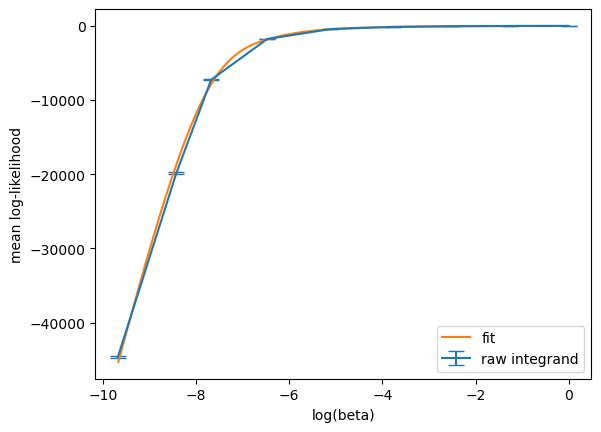

In [52]:
# Run .dat file of lnL chains through thermo_error.py
# Need support for customly-named outputs so that Neil's script doesn't simply rewrite all the output files for each iteration 
!python thermo_error.py lnlikechain_1.dat --steps 100000 --bootstrap-steps 10000

# Display some results
raw = np.loadtxt("rawintegrand.dat")
fit = np.loadtxt("fit.dat")

x = raw[:, 0]
y = raw[:, 1]
err = raw[:, 2]

plt.errorbar(x, y, yerr=err, capsize=6, label="raw integrand")
plt.plot(fit[:, 0], fit[:, 1], "-", label="fit")
plt.xlabel("log(beta)")
plt.ylabel("mean log-likelihood")
plt.legend()
plt.show()

In [ ]:
#### funny: the logLchain.dat file has a gross mismatch btwn raw integrand and fit, but my lnlikechain_i.dat files don't? !!